# Capstone Project Module 2
## Revenue Leakage & Billing Anomaly Analysis in Sinarmas Land Township Management

Sinarmas Land memiliki recurring revenue dari IPL, utilitas air, dan pengelolaan kawasan. Namun, peningkatan tunggakan IPL, banyaknya unit vacant, missing contact number, serta anomali pencatatan tagihan air dapat mengganggu cashflow operasional township management.

Analisis ini bertujuan untuk mengidentifikasi township, cluster, dan unit dengan risiko tunggakan tertinggi, mengevaluasi kualitas data collection dan billing, serta memberikan rekomendasi operasional untuk meningkatkan efektivitas collection dan validasi sistem billing.

## Import Library

In [ ]:
#data manipulation
import pandas as pd
import numpy as np

#statistik
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency


#data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


#connect ke Google Big Query
import pandas_gbq

#akses api key ke akun google bigquery
from google.oauth2 import service_account


#warning
import warnings
warnings.filterwarnings('ignore')


## Big Query Configuration

In [ ]:

# BigQuery configurations
key_path = 'premium-client-473107-s7-8973a6bc9cc3.json'

scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    key_path,
    scopes=scopes
)

project_id = 'premium-client-473107-s7'
dataset_id = 'sinarmas_land'  # ganti sesuai dataset kamu

## Exctract Data from Bigquery


In [ ]:
sql_query = f"""
select C.* , U.*, I.*
from `{project_id}.{dataset_id}.clusters` C
left join `{project_id}.{dataset_id}.units` U
on C.cluster_id = U.cluster_id
left join `{project_id}.{dataset_id}.ipl_billings` I
on U.unit_id = I.unit_id
"""

df = pandas_gbq.read_gbq(
    sql_query,
    project_id=project_id,
    credentials=credentials
)

df

Downloading: 100%|██████████|


,cluster_id,township_name,cluster_category,unit_id,cluster_id_1,owner_name,contact_number,is_vacant,handover_date,invoice_id,unit_id_1,billing_month,water_usage_m3,ipl_base_fee,total_amount,payment_status,payment_method,payment_date
0,CLS-SML-023,BSD City,Commercial Ruko,UNT-00411,CLS-SML-023,Pemilik Properti 410,<NA>,False,2022-06-09,INV-IPL-00153757,UNT-00411,2024-05,13.0,500000,597500.0,Overdue,None,NaT
1,CLS-SML-023,BSD City,Commercial Ruko,UNT-00411,CLS-SML-023,Pemilik Properti 410,<NA>,False,2022-06-09,INV-IPL-00258754,UNT-00411,2023-09,32.0,850000,1090000.0,Unpaid,None,NaT
2,CLS-SML-023,BSD City,Commercial Ruko,UNT-00411,CLS-SML-023,Pemilik Properti 410,<NA>,False,2022-06-09,INV-IPL-00207964,UNT-00411,2024-02,34.0,350000,605000.0,Paid,BCA Virtual Account,2024-02-25
3,CLS-SML-023,BSD City,Commercial Ruko,UNT-00411,CLS-SML-023,Pemilik Properti 410,<NA>,False,2022-06-09,INV-IPL-00026481,UNT-00411,2023-11,17.0,500000,627500.0,Paid,Credit Card,2023-11-15
4,CLS-SML-023,BSD City,Commercial Ruko,UNT-00411,CLS-SML-023,Pemilik Properti 410,<NA>,False,2022-06-09,INV-IPL-00173237,UNT-00411,2023-10,45.0,850000,1187500.0,Paid,Credit Card,2023-10-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,CLS-SML-098,NavaPark,Premium Residential,UNT-24952,CLS-SML-098,Pemilik Properti 24951,8190652073,True,2021-02-19,INV-IPL-00243757,UNT-24952,2024-03,2.0,500000,515000.0,Unpaid,None,NaT
299996,CLS-SML-098,NavaPark,Premium Residential,UNT-24952,CLS-SML-098,Pemilik Properti 24951,8190652073,True,2021-02-19,INV-IPL-00025501,UNT-24952,2024-11,2.0,850000,865000.0,Unpaid,None,NaT
299997,CLS-SML-098,NavaPark,Premium Residential,UNT-24952,CLS-SML-098,Pemilik Properti 24951,8190652073,True,2021-02-19,INV-IPL-00105707,UNT-24952,2024-10,2.0,1500000,1515000.0,Overdue,None,NaT
299998,CLS-SML-098,NavaPark,Premium Residential,UNT-24952,CLS-SML-098,Pemilik Properti 24951,8190652073,True,2021-02-19,INV-IPL-00231813,UNT-24952,2024-04,2.0,1500000,1515000.0,Unpaid,None,NaT


## Data Cleaning

In [ ]:
## Cek Data Missing

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent (%)": df.isnull().sum() / len(df) * 100
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]
missing_summary.sort_values("Missing Percent (%)", ascending=False)

,Missing Count,Missing Percent (%)
payment_method,90278,30.092667
payment_date,90278,30.092667
contact_number,60046,20.015333


In [ ]:
# Cek Payment Methode

df['payment_method'].unique()

array([None, 'BCA Virtual Account', 'Credit Card', 'bca va', 'toped',
       'Cash', 'VA BCA', 'KAS', 'cc', 'Tokopedia'], dtype=object)

In [ ]:
# Jumlah Data Payment Methode Before (Belum Standard)
payment_before = (
    df['payment_method']
    .value_counts(dropna=False)
    .reset_index()
)

payment_before.columns = ['payment_method_raw', 'count']
payment_before

,payment_method_raw,count
0,None,90278
1,toped,23449
2,KAS,23438
3,Cash,23370
4,cc,23302
5,Credit Card,23267
6,bca va,23242
7,Tokopedia,23238
8,BCA Virtual Account,23216
9,VA BCA,23200


In [ ]:
# Simpan payment method original
df['payment_method_old'] = df['payment_method']

# Rename / standardisasi payment method
df['payment_method'] = df['payment_method'].replace({
    'bca va': 'BCA Virtual Account',
    'toped': 'Tokopedia',
    'VA BCA': 'BCA Virtual Account',
    'KAS': 'Cash',
    'cc': 'Credit Card'
})

In [ ]:
# Jumlah Data Payment Methode After (Standard)
payment_after = (
    df['payment_method']
    .value_counts(dropna=False)
    .reset_index()
)

payment_after.columns = ['payment_method_clean', 'count']
payment_after

,payment_method_clean,count
0,None,90278
1,BCA Virtual Account,69658
2,Cash,46808
3,Tokopedia,46687
4,Credit Card,46569


## Visualisasi & Analisis Statistik

Buat Kolom Baru 'aging_tunggakan_bulan'

In [ ]:
# Buat billing_date dari billing_month
df['billing_date'] = pd.to_datetime(
    df['billing_month'].astype(str).str.strip() + '-01',
    errors='coerce'
)

# Tanggal analisis adalah Tanggal Billing Terakhir
analysis_date = df['billing_date'].max()

# Aging tunggakan dari bulan tagihan sampai tanggal analisis
df['aging_tunggakan_bulan'] = (
    (analysis_date.year - df['billing_date'].dt.year) * 12 +
    (analysis_date.month - df['billing_date'].dt.month)
)

# Hanya relevan untuk yang belum paid
df['aging_tunggakan_bulan'] = np.where(
    df['payment_status'] != 'Paid',
    df['aging_tunggakan_bulan'],
    0
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   cluster_id             300000 non-null  object        
 1   township_name          300000 non-null  object        
 2   cluster_category       300000 non-null  object        
 3   unit_id                300000 non-null  object        
 4   cluster_id_1           300000 non-null  object        
 5   owner_name             300000 non-null  object        
 6   contact_number         239954 non-null  Int64         
 7   is_vacant              300000 non-null  boolean       
 8   handover_date          300000 non-null  dbdate        
 9   invoice_id             300000 non-null  object        
 10  unit_id_1              300000 non-null  object        
 11  billing_month          300000 non-null  object        
 12  water_usage_m3         300000 non-null  floa

In [ ]:
df['aging_bucket'] = pd.cut(
    df['aging_tunggakan_bulan'],
    bins=[-1, 0, 3, 6, 999],
    labels=['Paid / Current', '1-3 Bulan', '4-6 Bulan', '>6 Bulan']
)

In [ ]:
# Invoice dikategorikan sebagai tunggakan apabila payment_status bernilai Unpaid atau Overdue. Status Paid tidak dimasukkan sebagai tunggakan.
# Rasio Tunggakan by Township dan Cluster

df['is_tunggakan'] = df['payment_status'].isin(['Unpaid', 'Overdue'])

summary_tunggakan_township = (
    df.groupby('township_name')
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        tunggakan_invoice=('is_tunggakan', 'sum'),
        total_amount=('total_amount', 'sum'),
        tunggakan_amount=('total_amount', lambda x: x[df.loc[x.index, 'is_tunggakan']].sum()),
        total_unit=('unit_id', 'nunique')
    )
    .reset_index()
)

summary_tunggakan_township['tunggakan_rate_invoice'] = (
    summary_tunggakan_township['tunggakan_invoice'] /
    summary_tunggakan_township['total_invoice'] * 100
).round(2)

summary_tunggakan_township['tunggakan_rate_amount'] = (
    summary_tunggakan_township['tunggakan_amount'] /
    summary_tunggakan_township['total_amount'] * 100
).round(2)

summary_tunggakan_township.sort_values('tunggakan_rate_amount', ascending=False)

,township_name,total_invoice,tunggakan_invoice,total_amount,tunggakan_amount,total_unit,tunggakan_rate_invoice,tunggakan_rate_amount
3,Kota Wisata,74662,22665,9.988885e+10,2.987024e+10,6238,30.36,29.90
2,Grand Wisata,71729,21569,9.481837e+10,2.815073e+10,5980,30.07,29.69
0,BSD City,99808,29808,1.353813e+11,3.904476e+10,8298,29.87,28.84
4,NavaPark,12445,3787,1.681490e+10,4.843682e+09,1014,30.43,28.81
1,Deltamas,41356,12449,5.387572e+10,1.534981e+10,3470,30.10,28.49


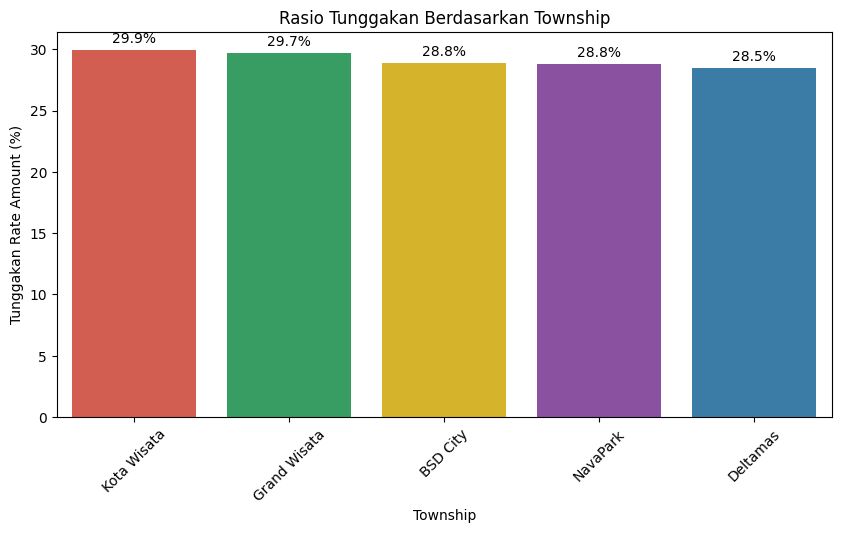

In [ ]:
# Grafik Bar Plot Rasio Tunggakan Berdasarkan Township

township_palette = {
    'Kota Wisata': '#E74C3C',   # merah
    'Grand Wisata': '#27AE60',  # hijau
    'BSD City': '#F1C40F',      # kuning
    'NavaPark': '#8E44AD',      # ungu
    'Deltamas': '#2980B9'       # biru
}

plt.figure(figsize=(10,5))

grafik = sns.barplot(
    data=summary_tunggakan_township.sort_values('tunggakan_rate_amount', ascending=False),
    x='township_name',
    y='tunggakan_rate_amount',
    hue='township_name',
    palette=township_palette,
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.1f%%', padding=3)

plt.title('Rasio Tunggakan Berdasarkan Township')
plt.xlabel('Township')
plt.ylabel('Tunggakan Rate Amount (%)')
plt.xticks(rotation=45)
plt.show()

In [ ]:
summary_tunggakan_cluster = (
    df.groupby(['township_name', 'cluster_id', 'cluster_category'])
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        tunggakan_invoice=('is_tunggakan', 'sum'),
        total_amount=('total_amount', 'sum'),
        tunggakan_amount=('total_amount', lambda x: x[df.loc[x.index, 'is_tunggakan']].sum()),
        total_unit=('unit_id', 'nunique')
    )
    .reset_index()
)

summary_tunggakan_cluster['tunggakan_rate_invoice'] = (
    summary_tunggakan_cluster['tunggakan_invoice'] /
    summary_tunggakan_cluster['total_invoice'] * 100
).round(2)

summary_tunggakan_cluster['tunggakan_rate_amount'] = (
    summary_tunggakan_cluster['tunggakan_amount'] /
    summary_tunggakan_cluster['total_amount'] * 100
).round(2)

summary_tunggakan_cluster.sort_values(
    'tunggakan_rate_amount',
    ascending=False
).head(10)

,township_name,cluster_id,cluster_category,total_invoice,tunggakan_invoice,total_amount,tunggakan_amount,total_unit,tunggakan_rate_invoice,tunggakan_rate_amount
57,Grand Wisata,CLS-SML-036,Middle Residential,2708,800,3.225208e+09,1.210818e+09,226,29.54,37.54
36,Deltamas,CLS-SML-025,Middle Residential,2963,969,3.738138e+09,1.330318e+09,244,32.70,35.59
84,Kota Wisata,CLS-SML-067,Middle Residential,3111,1061,3.679962e+09,1.298265e+09,254,34.10,35.28
0,BSD City,CLS-SML-001,Middle Residential,3036,958,4.175300e+09,1.457968e+09,246,31.55,34.92
88,Kota Wisata,CLS-SML-078,Commercial Ruko,3394,1061,4.440925e+09,1.545685e+09,279,31.26,34.81
81,Kota Wisata,CLS-SML-050,Middle Residential,2769,776,3.415712e+09,1.175932e+09,228,28.02,34.43
23,BSD City,CLS-SML-066,Middle Residential,3127,989,4.303972e+09,1.477230e+09,257,31.63,34.32
74,Kota Wisata,CLS-SML-017,Commercial Ruko,3154,980,5.019115e+09,1.721330e+09,261,31.07,34.30
95,Kota Wisata,CLS-SML-097,Middle Residential,2872,940,3.594995e+09,1.226710e+09,240,32.73,34.12
64,Grand Wisata,CLS-SML-071,Middle Residential,3162,906,4.436350e+09,1.509520e+09,265,28.65,34.03


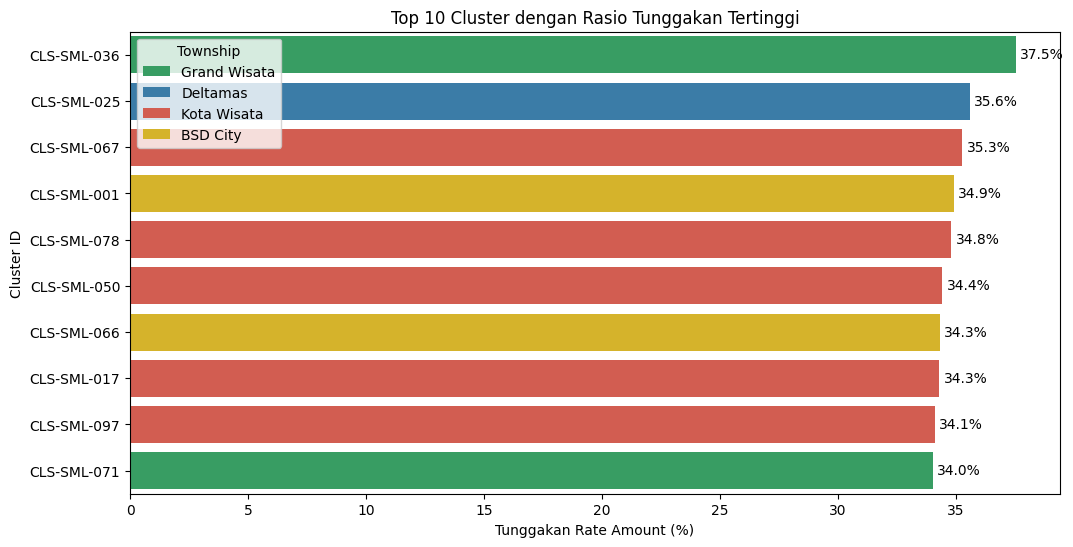

In [ ]:
# Grafik Bar Top 10 Cluster dengan Rasio Tunggakan Tertinggi
top_cluster = summary_tunggakan_cluster.sort_values(
    'tunggakan_rate_amount',
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

grafik = sns.barplot(
    data=top_cluster,
    x='tunggakan_rate_amount',
    y='cluster_id',
    hue='township_name',
    palette=township_palette,
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.1f%%', padding=3)

plt.title('Top 10 Cluster dengan Rasio Tunggakan Tertinggi')
plt.xlabel('Tunggakan Rate Amount (%)')
plt.ylabel('Cluster ID')
plt.legend(title='Township')
plt.show()

In [ ]:
# Buat kolom Occupancy Status di dataframe utama
df['occupancy_status'] = df['is_vacant'].astype(str).replace({
    'True': 'Vacant',
    'False': 'Occupied'
})

# Analisis Vacant vs Occupied
summary_vacant = (
    df.groupby(['township_name', 'occupancy_status'])
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        tunggakan_invoice=('is_tunggakan', 'sum'),
        total_amount=('total_amount', 'sum'),
        tunggakan_amount=('total_amount', lambda x: x[df.loc[x.index, 'is_tunggakan']].sum()),
        total_unit=('unit_id', 'nunique')
    )
    .reset_index()
)

summary_vacant['tunggakan_rate_invoice'] = (
    summary_vacant['tunggakan_invoice'] /
    summary_vacant['total_invoice'] * 100
).round(2)

summary_vacant['tunggakan_rate_amount'] = (
    summary_vacant['tunggakan_amount'] /
    summary_vacant['total_amount'] * 100
).round(2)

summary_vacant

,township_name,occupancy_status,total_invoice,tunggakan_invoice,total_amount,tunggakan_amount,total_unit,tunggakan_rate_invoice,tunggakan_rate_amount
0,BSD City,Occupied,75181,15050,1.066908e+11,2.174378e+10,6250,20.02,20.38
1,BSD City,Vacant,24627,14758,2.869043e+10,1.730098e+10,2048,59.93,60.30
2,Deltamas,Occupied,30933,6155,4.194420e+10,8.287328e+09,2601,19.90,19.76
3,Deltamas,Vacant,10423,6294,1.193152e+10,7.062482e+09,869,60.39,59.19
4,Grand Wisata,Occupied,53728,10795,7.359487e+10,1.575711e+10,4503,20.09,21.41
5,Grand Wisata,Vacant,18001,10774,2.122350e+10,1.239362e+10,1477,59.85,58.40
6,Kota Wisata,Occupied,56323,11594,7.803556e+10,1.589667e+10,4705,20.58,20.37
7,Kota Wisata,Vacant,18339,11071,2.185328e+10,1.397357e+10,1533,60.37,63.94
8,NavaPark,Occupied,9327,1905,1.325256e+10,2.823562e+09,763,20.42,21.31
9,NavaPark,Vacant,3118,1882,3.562342e+09,2.020120e+09,251,60.36,56.71


In [ ]:
# Perbaiki Revenue Tertunda >6 Bulan

revenue_tertunda_6_bulan = df[
    (df['payment_status'] != 'Paid') &
    (df['aging_tunggakan_bulan'] > 6)
]

summary_revenue_tertunda = (
    revenue_tertunda_6_bulan.groupby('township_name')
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        total_unit=('unit_id', 'nunique'),
        potential_revenue_loss=('total_amount', 'sum')
    )
    .reset_index()
    .sort_values('potential_revenue_loss', ascending=False)
)

summary_revenue_tertunda

,township_name,total_invoice,total_unit,potential_revenue_loss
0,BSD City,21050,7171,2.787999e+10
3,Kota Wisata,16058,5411,2.073032e+10
2,Grand Wisata,15311,5137,1.962389e+10
1,Deltamas,8784,2963,1.103396e+10
4,NavaPark,2621,880,3.241392e+09


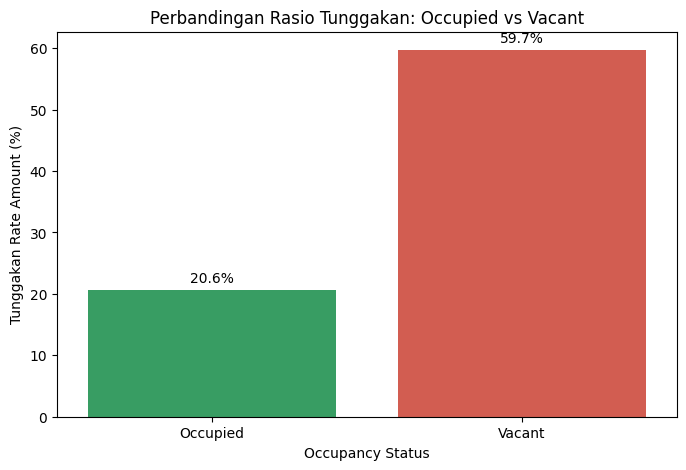

In [ ]:
# Grafik Bar Perbandingan Rasio Tunggakan: Occupied vs Vacant

vacant_palette = {
    'Vacant': '#E74C3C',
    'Occupied': '#27AE60'
}

plt.figure(figsize=(8, 5))

grafik = sns.barplot(
    data=summary_vacant,
    x='occupancy_status',
    y='tunggakan_rate_amount',
    hue='occupancy_status',
    palette=vacant_palette,
    order=['Occupied', 'Vacant'],
    errorbar=None,
    legend=False
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.1f%%', padding=3)

plt.title('Perbandingan Rasio Tunggakan: Occupied vs Vacant')
plt.xlabel('Occupancy Status')
plt.ylabel('Tunggakan Rate Amount (%)')
plt.show()

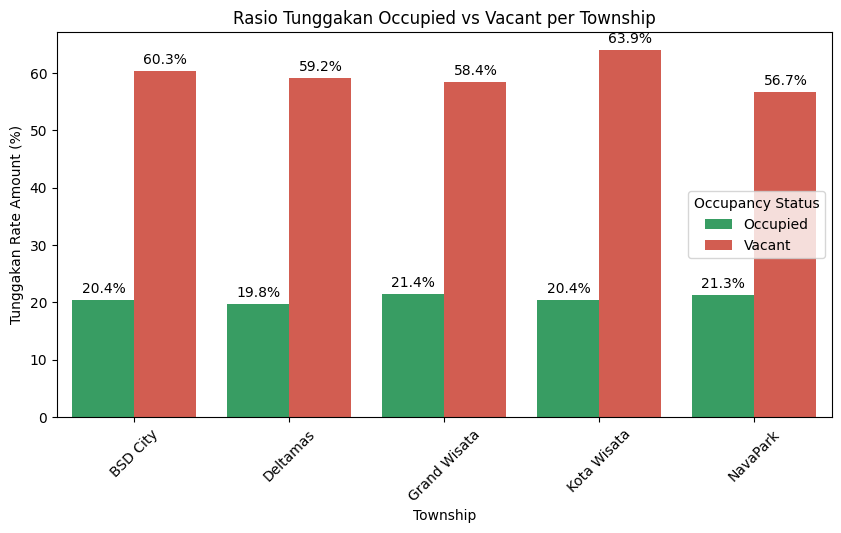

In [ ]:
# Bar Plot : Rasio Tunggakan Occupied vs Vacant per Township

vacant_palette = {
    'Vacant': '#E74C3C',
    'Occupied': '#27AE60'
}

plt.figure(figsize=(10, 5))

grafik = sns.barplot(
    data=summary_vacant,
    x='township_name',
    y='tunggakan_rate_amount',
    hue='occupancy_status',
    palette=vacant_palette,
    hue_order=['Occupied', 'Vacant'],
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.1f%%', padding=3)

plt.title('Rasio Tunggakan Occupied vs Vacant per Township')
plt.xlabel('Township')
plt.ylabel('Tunggakan Rate Amount (%)')
plt.xticks(rotation=45)
plt.legend(title='Occupancy Status')
plt.show()

In [ ]:
# Convert tanggal dulu
df['handover_date'] = pd.to_datetime(df['handover_date'], errors='coerce')
df['payment_date'] = pd.to_datetime(df['payment_date'], errors='coerce')
df['billing_date'] = pd.to_datetime(df['billing_month'], errors='coerce')

# Summary Anomali Paid Before Handover
df['paid_before_handover_status'] = np.where(
    (df['payment_status'] == 'Paid') &
    (df['payment_date'] < df['handover_date']),
    'Anomali',
    'Normal'
)

summary_anomali = (
    df.groupby('township_name')
    .agg(
        total_unit=('unit_id', 'nunique'),
        total_invoice=('invoice_id', 'nunique'),
        anomaly_invoice=('paid_before_handover_status', lambda x: (x == 'Anomali').sum()),
        anomaly_unit=('unit_id', lambda x: x[df.loc[x.index, 'paid_before_handover_status'].eq('Anomali')].nunique())
    )
    .reset_index()
)

summary_anomali['anomaly_unit_percent'] = (
    summary_anomali['anomaly_unit'] /
    summary_anomali['total_unit'] * 100
).round(2)

summary_anomali

,township_name,total_unit,total_invoice,anomaly_invoice,anomaly_unit,anomaly_unit_percent
0,BSD City,8298,99808,2107,1842,22.20
1,Deltamas,3470,41356,847,766,22.07
2,Grand Wisata,5980,71729,1538,1334,22.31
3,Kota Wisata,6238,74662,1568,1362,21.83
4,NavaPark,1014,12445,231,206,20.32


In [ ]:
# Paid Before Handover Anomaly
df['paid_before_handover_status'] = np.where(
    (df['payment_status'].astype(str).str.strip() == 'Paid') &
    (df['payment_date'] < df['handover_date']),
    'Anomali',
    'Normal'
)

df['paid_before_handover_amount'] = np.where(
    df['paid_before_handover_status'] == 'Anomali',
    df['total_amount'],
    0
)

# Kalkulasi Anomaly

df['paid_before_handover_status'].value_counts()
df.groupby('township_name').agg(
    anomaly_invoice=('invoice_id', lambda x: (df.loc[x.index, 'paid_before_handover_status'] == 'Anomali').sum()),
    anomaly_amount=('paid_before_handover_amount', 'sum')
).reset_index()

,township_name,anomaly_invoice,anomaly_amount
0,BSD City,2107,3.042252e+09
1,Deltamas,847,1.133082e+09
2,Grand Wisata,1538,1.820950e+09
3,Kota Wisata,1568,1.975260e+09
4,NavaPark,231,3.797250e+08


In [ ]:
# Missing Contact Number per Township

df['contact_missing_status'] = np.where(
    df['contact_number'].isna() |
    (df['contact_number'].astype(str).str.strip() == '') |
    (df['contact_number'].astype(str).str.lower().isin(['nan', 'none', 'null'])),
    'Missing Contact',
    'Contact Available'
)

summary_contact = (
    df.drop_duplicates('unit_id')
    .groupby('township_name')
    .agg(
        total_unit=('unit_id', 'nunique'),
        missing_contact=('contact_number', lambda x: x.isna().sum())
    )
    .reset_index()
)

summary_contact['missing_contact_percent'] = (
    summary_contact['missing_contact'] /
    summary_contact['total_unit'] * 100
).round(2)

summary_contact.sort_values('missing_contact_percent', ascending=False)

,township_name,total_unit,missing_contact,missing_contact_percent
3,Kota Wisata,6238,1297,20.79
4,NavaPark,1014,208,20.51
1,Deltamas,3470,708,20.4
0,BSD City,8298,1635,19.7
2,Grand Wisata,5980,1152,19.26


<Axes: xlabel='cluster_category', ylabel='water_usage_m3'>

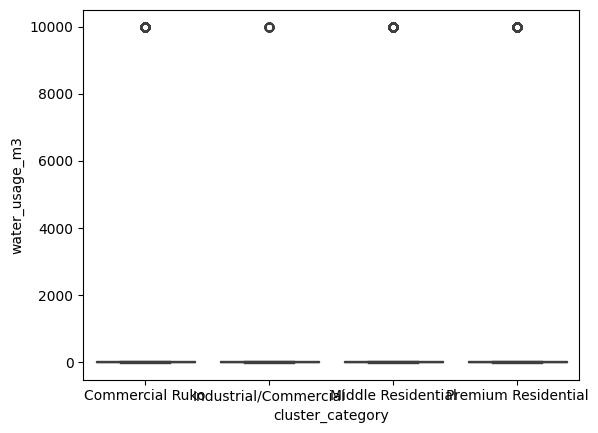

In [ ]:
# Boxplot : Identifikasi Outliers pada Water Usage per Cluster Category

sns.boxplot(
    data=df,
    x='cluster_category',
    y='water_usage_m3',
    )

In [ ]:
# Kolom yang dicek
col = 'water_usage_m3'
group_col = 'cluster_category'

# Hitung Q1, Q3, dan IQR per cluster_category
summary_outlier = (
    df.groupby(group_col)[col]
    .agg(
        total_data='count',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

summary_outlier['IQR'] = summary_outlier['Q3'] - summary_outlier['Q1']

# Batas outlier ekstrem
summary_outlier['lower_extreme'] = summary_outlier['Q1'] - 3 * summary_outlier['IQR']
summary_outlier['upper_extreme'] = summary_outlier['Q3'] + 3 * summary_outlier['IQR']

# Gabungkan batas outlier ke data utama
df_outlier = df.merge(
    summary_outlier[[group_col, 'lower_extreme', 'upper_extreme']],
    on=group_col,
    how='left'
)

# Buat status outlier
df_outlier['water_outlier_status'] = np.where(
    (df_outlier[col] < df_outlier['lower_extreme']) |
    (df_outlier[col] > df_outlier['upper_extreme']),
    'Extreme Outlier',
    'Normal'
)

# Summary outlier per township dan cluster category
summary_outlier_township_cluster = (
    df_outlier.groupby(['township_name', 'cluster_category'])
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        extreme_outlier_count=(
            'water_outlier_status',
            lambda x: (x == 'Extreme Outlier').sum()
        )
    )
    .reset_index()
)

summary_outlier_township_cluster['extreme_outlier_percent'] = (
    summary_outlier_township_cluster['extreme_outlier_count'] /
    summary_outlier_township_cluster['total_invoice'] * 100
).round(2)

summary_outlier_township_cluster

,township_name,cluster_category,total_invoice,extreme_outlier_count,extreme_outlier_percent
0,BSD City,Commercial Ruko,12015,78,0.65
1,BSD City,Middle Residential,63324,324,0.51
2,BSD City,Premium Residential,24469,117,0.48
3,Deltamas,Industrial/Commercial,14063,53,0.38
4,Deltamas,Middle Residential,27293,134,0.49
5,Grand Wisata,Commercial Ruko,11609,57,0.49
6,Grand Wisata,Middle Residential,50851,252,0.50
7,Grand Wisata,Premium Residential,9269,30,0.32
8,Kota Wisata,Commercial Ruko,17892,105,0.59
9,Kota Wisata,Middle Residential,41449,191,0.46


Baseline rata-rata Extreme Outlier: 0.49%


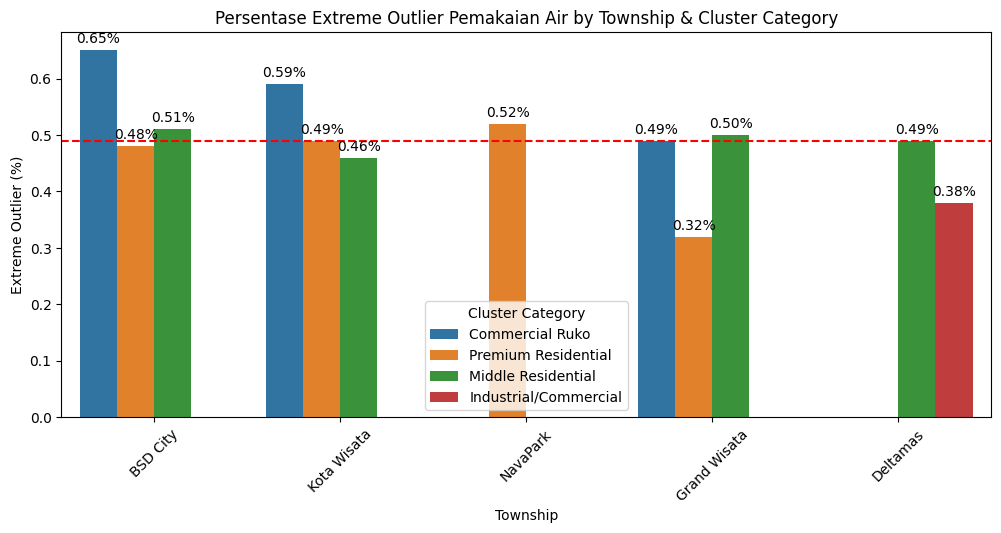

In [ ]:
# Baseline rata-rata rasio extreme outlier
baseline_outlier = summary_outlier_township_cluster['extreme_outlier_percent'].mean()

print(f'Baseline rata-rata Extreme Outlier: {baseline_outlier:.2f}%')

plt.figure(figsize=(12, 5))

grafik = sns.barplot(
    data=summary_outlier_township_cluster.sort_values(
        'extreme_outlier_percent',
        ascending=False
    ),
    x='township_name',
    y='extreme_outlier_percent',
    hue='cluster_category',
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.2f%%', padding=3)

# Garis baseline rata-rata
grafik.axhline(
    baseline_outlier,
    linestyle='--',
    linewidth=1.5,
    color='red'
)

# # Label nilai baseline di grafik
# grafik.text(
#     x=-0.45,
#     y=baseline_outlier + 0.05,
#     s=f'Baseline Avg: {baseline_outlier:.2f}%',
#     color='red',
#     fontsize=10,
#     fontweight='bold'
# )

plt.title('Persentase Extreme Outlier Pemakaian Air by Township & Cluster Category')
plt.xlabel('Township')
plt.ylabel('Extreme Outlier (%)')
plt.xticks(rotation=45)
plt.legend(title='Cluster Category')
plt.show()

Avg Water Ratio     : 8.33%
Avg Tunggakan Rate  : 28.48%


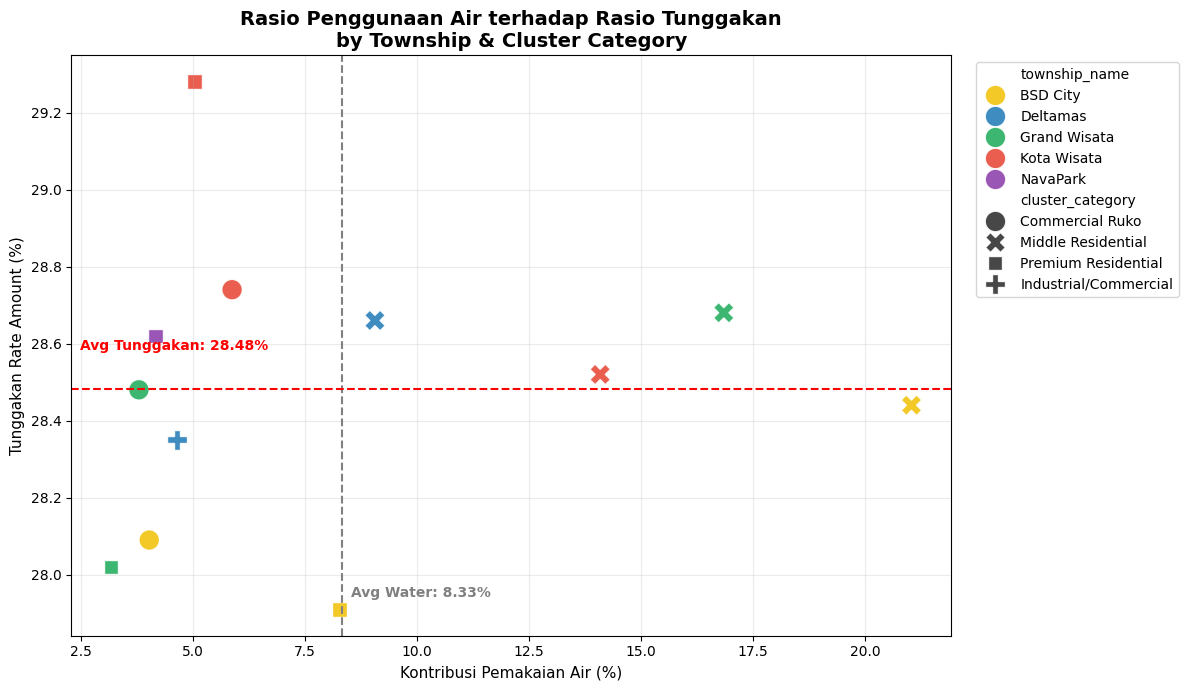

,township_name,cluster_category,total_invoice,total_water_usage,total_billing_amount,tunggakan_amount,water_usage_ratio,tunggakan_rate_amount
0,BSD City,Commercial Ruko,11937,267021.0,1.153776e+10,3.240985e+09,4.02,28.09
1,BSD City,Middle Residential,63000,1397045.0,6.087299e+10,1.730944e+10,21.04,28.44
2,BSD City,Premium Residential,24352,548927.0,2.363360e+10,6.594958e+09,8.27,27.91
3,Deltamas,Industrial/Commercial,14010,308395.0,1.353026e+10,3.836315e+09,4.64,28.35
4,Deltamas,Middle Residential,27159,601761.0,2.616516e+10,7.499392e+09,9.06,28.66
5,Grand Wisata,Commercial Ruko,11552,251773.0,1.118190e+10,3.184335e+09,3.79,28.48
6,Grand Wisata,Middle Residential,50599,1119285.0,4.889669e+10,1.402227e+10,16.85,28.68
7,Grand Wisata,Premium Residential,9239,210617.0,9.034678e+09,2.531658e+09,3.17,28.02
8,Kota Wisata,Commercial Ruko,17787,389969.0,1.713997e+10,4.926672e+09,5.87,28.74
9,Kota Wisata,Middle Residential,41258,935837.0,3.993803e+10,1.138868e+10,14.09,28.52


In [ ]:
# Scatter Plot: Rasio Penggunaan Air vs Rasio Tunggakan

# Gunakan data tanpa extreme water outlier
df_water_clean = df_outlier[
    df_outlier['water_outlier_status'] == 'Normal'
].copy()

# Summary per Township & Cluster Category
summary_water_tunggakan_tc = (
    df_water_clean.groupby(['township_name', 'cluster_category'])
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        total_water_usage=('water_usage_m3', 'sum'),
        total_billing_amount=('total_amount', 'sum'),
        tunggakan_amount=(
            'total_amount',
            lambda x: x[
                df_water_clean.loc[x.index, 'payment_status'].isin(['Unpaid', 'Overdue'])
            ].sum()
        )
    )
    .reset_index()
)

# Rasio penggunaan air terhadap total penggunaan air seluruh group
summary_water_tunggakan_tc['water_usage_ratio'] = (
    summary_water_tunggakan_tc['total_water_usage'] /
    summary_water_tunggakan_tc['total_water_usage'].sum() * 100
).round(2)

# Rasio tunggakan amount per group
summary_water_tunggakan_tc['tunggakan_rate_amount'] = (
    summary_water_tunggakan_tc['tunggakan_amount'] /
    summary_water_tunggakan_tc['total_billing_amount'] * 100
).round(2)

# Baseline
baseline_water_ratio = summary_water_tunggakan_tc['water_usage_ratio'].mean()
baseline_tunggakan_rate = summary_water_tunggakan_tc['tunggakan_rate_amount'].mean()

print(f'Avg Water Ratio     : {baseline_water_ratio:.2f}%')
print(f'Avg Tunggakan Rate  : {baseline_tunggakan_rate:.2f}%')

# ============================================================
# Visualisasi Scatter Plot
# ============================================================

plt.figure(figsize=(12, 7))

grafik = sns.scatterplot(
    data=summary_water_tunggakan_tc,
    x='water_usage_ratio',
    y='tunggakan_rate_amount',
    hue='township_name',
    style='cluster_category',
    palette=township_palette,
    s=220,
    alpha=0.9,
    edgecolor='white',
    linewidth=1
)

# Baseline
plt.axvline(
    baseline_water_ratio,
    linestyle='--',
    linewidth=1.5,
    color='gray'
)

plt.axhline(
    baseline_tunggakan_rate,
    linestyle='--',
    linewidth=1.5,
    color='red'
)

# Label baseline
x_min, x_max = plt.xlim()
y_min, y_max = plt.ylim()

plt.text(
    x_min + 0.2,
    baseline_tunggakan_rate + 0.1,
    f'Avg Tunggakan: {baseline_tunggakan_rate:.2f}%',
    color='red',
    fontsize=10,
    fontweight='bold'
)

plt.text(
    baseline_water_ratio + 0.2,
    y_min + 0.1,
    f'Avg Water: {baseline_water_ratio:.2f}%',
    color='gray',
    fontsize=10,
    fontweight='bold'
)

plt.title(
    'Rasio Penggunaan Air terhadap Rasio Tunggakan\nby Township & Cluster Category',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Kontribusi Pemakaian Air (%)', fontsize=11)
plt.ylabel('Tunggakan Rate Amount (%)', fontsize=11)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

summary_water_tunggakan_tc

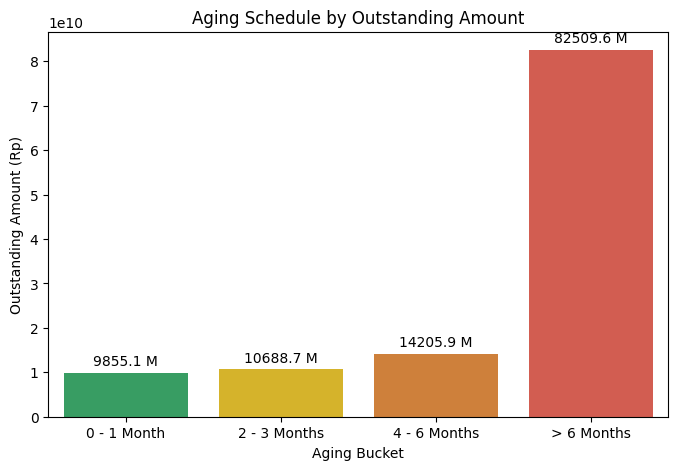

In [ ]:
# Aging Schedule per Bulan
df['billing_date'] = pd.to_datetime(df['billing_date'], errors='coerce')

df['aging_month'] = np.where(
    df['payment_status'].isin(['Unpaid', 'Overdue']),
    ((analysis_date.year - df['billing_date'].dt.year) * 12) +
    (analysis_date.month - df['billing_date'].dt.month),
    0
)

df['aging_bucket'] = np.select(
    [
        df['aging_month'].between(0, 1),
        df['aging_month'].between(2, 3),
        df['aging_month'].between(4, 6),
        df['aging_month'] > 6
    ],
    [
        '0 - 1 Month',
        '2 - 3 Months',
        '4 - 6 Months',
        '> 6 Months'
    ],
    default='Paid'
)

aging_summary = (
    df[df['payment_status'].isin(['Unpaid', 'Overdue'])]
    .groupby('aging_bucket')
    .agg(
        total_invoice=('invoice_id', 'count'),
        total_unit=('unit_id', 'nunique'),
        outstanding_amount=('total_amount', 'sum')
    )
    .reset_index()
)

aging_order = ['0 - 1 Month', '2 - 3 Months', '4 - 6 Months', '> 6 Months']

plt.figure(figsize=(8, 5))

grafik = sns.barplot(
    data=aging_summary,
    x='aging_bucket',
    y='outstanding_amount',
    order=aging_order,
    hue='aging_bucket',
    palette=['#27AE60', '#F1C40F', '#E67E22', '#E74C3C'],
    legend=False
)

for i in grafik.containers:
    grafik.bar_label(i, labels=[f'{v/1_000_000:.1f} M' for v in i.datavalues], padding=3)

plt.title('Aging Schedule by Outstanding Amount')
plt.xlabel('Aging Bucket')
plt.ylabel('Outstanding Amount (Rp)')
plt.show()

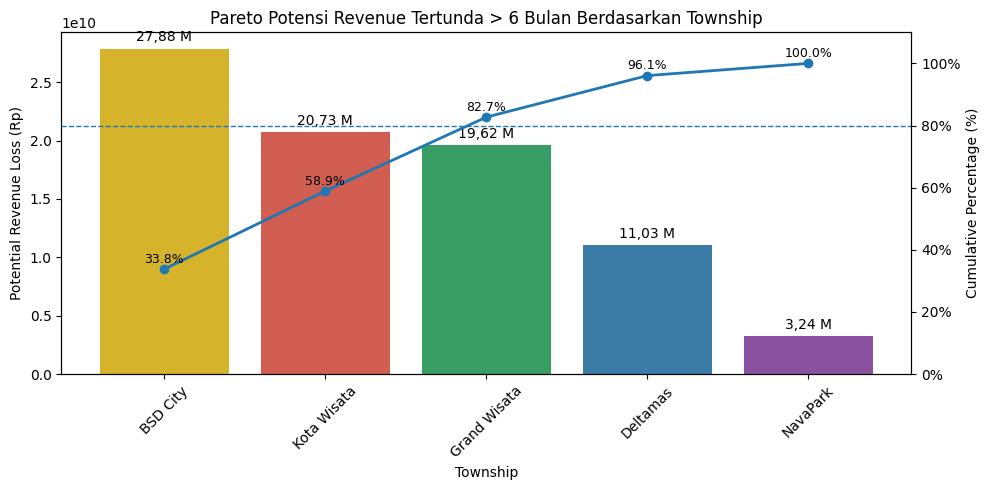

In [ ]:
# Data Pareto
pareto_df = summary_revenue_tertunda.sort_values(
    'potential_revenue_loss', ascending=False
).copy()

pareto_df['cum_revenue'] = pareto_df['potential_revenue_loss'].cumsum()
pareto_df['cum_pct'] = pareto_df['cum_revenue'] / pareto_df['potential_revenue_loss'].sum() * 100

# Format angka ringkas
def format_rupiah_ringkas(x):
    if x >= 1_000_000_000:
        return f'{x/1_000_000_000:.2f} M'.replace('.', ',')
    elif x >= 1_000_000:
        return f'{x/1_000_000:.2f} Jt'.replace('.', ',')
    elif x >= 1_000:
        return f'{x/1_000:.2f} Rb'.replace('.', ',')
    else:
        return f'{x:.0f}'

plt.figure(figsize=(10,5))

ax1 = sns.barplot(
    data=pareto_df,
    x='township_name',
    y='potential_revenue_loss',
    hue='township_name',
    palette=township_palette,
    errorbar=None,
    dodge=False,
    legend=False
)

# Label bar
for container in ax1.containers:
    ax1.bar_label(
        container,
        labels=[format_rupiah_ringkas(v) for v in container.datavalues],
        padding=3
    )

ax1.set_title('Pareto Potensi Revenue Tertunda > 6 Bulan Berdasarkan Township')
ax1.set_xlabel('Township')
ax1.set_ylabel('Potential Revenue Loss (Rp)')
ax1.tick_params(axis='x', rotation=45)

# Axis kedua untuk cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    pareto_df['township_name'],
    pareto_df['cum_pct'],
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Cumulative Percentage (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 110)

# Label cumulative percentage
for x, y in zip(pareto_df['township_name'], pareto_df['cum_pct']):
    ax2.text(
        x, y + 2,
        f'{y:.1f}%',
        ha='center',
        fontsize=9
    )

# Garis referensi 80%
ax2.axhline(80, linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

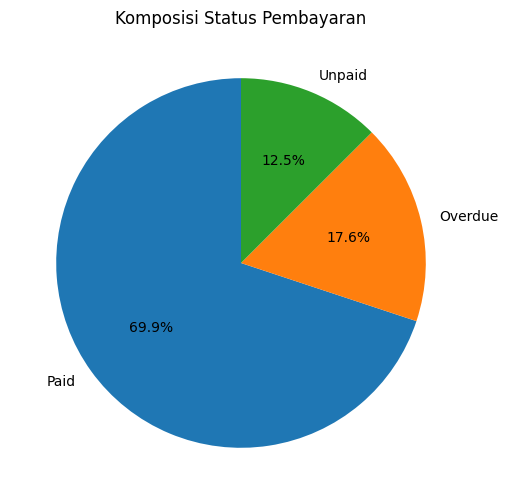

In [ ]:
# Pie Chart Komposisi Status Pembayaran

payment_status_summary = df['payment_status'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    payment_status_summary.values,
    labels=payment_status_summary.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Komposisi Status Pembayaran')
plt.show()

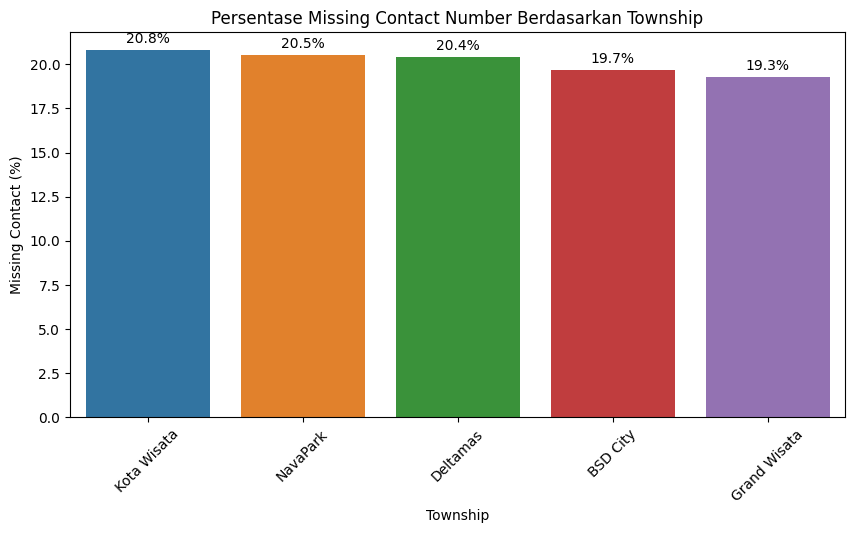

In [ ]:
# Bar Plot Persentase Missing Contact Number Berdasarkan Township

plt.figure(figsize=(10,5))

grafik = sns.barplot(
    data=summary_contact.sort_values('missing_contact_percent', ascending=False),
    x='township_name',
    y='missing_contact_percent',
    hue='township_name',
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.1f%%', padding=3)

plt.title('Persentase Missing Contact Number Berdasarkan Township')
plt.xlabel('Township')
plt.ylabel('Missing Contact (%)')
plt.xticks(rotation=45)
plt.show()

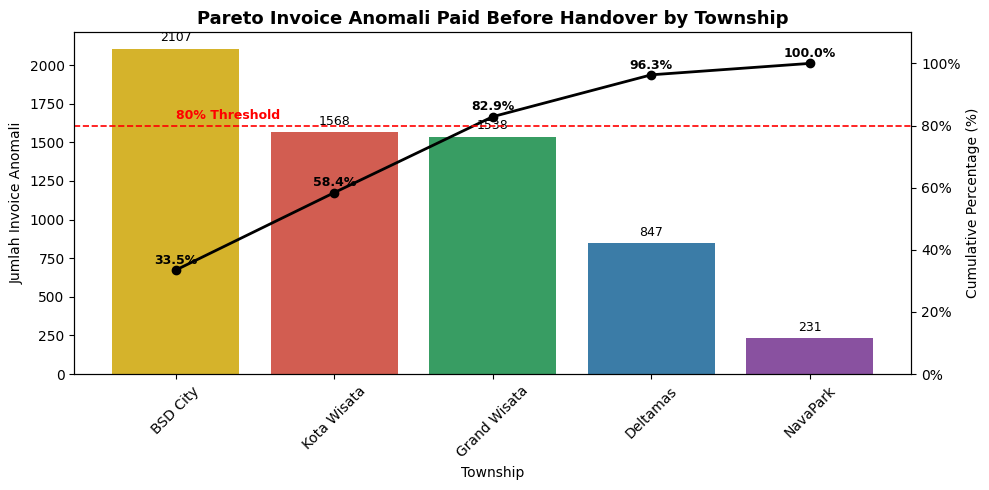

,township_name,anomaly_invoice,anomaly_amount,cum_invoice,cum_pct
0,BSD City,2107,3.042252e+09,2107,33.492291
3,Kota Wisata,1568,1.975260e+09,3675,58.416786
2,Grand Wisata,1538,1.820950e+09,5213,82.864409
1,Deltamas,847,1.133082e+09,6060,96.328088
4,NavaPark,231,3.797250e+08,6291,100.000000


In [ ]:
# Summary jumlah invoice anomali by township
pareto_anomali_township = (
    df[df['paid_before_handover_status'] == 'Anomali']
    .groupby('township_name')
    .agg(
        anomaly_invoice=('invoice_id', 'nunique'),
        anomaly_amount=('paid_before_handover_amount', 'sum')
    )
    .reset_index()
    .sort_values('anomaly_invoice', ascending=False)
)

# Hitung cumulative percentage
pareto_anomali_township['cum_invoice'] = pareto_anomali_township['anomaly_invoice'].cumsum()

pareto_anomali_township['cum_pct'] = (
    pareto_anomali_township['cum_invoice'] /
    pareto_anomali_township['anomaly_invoice'].sum() * 100
)

# ============================================================
# Visualisasi Pareto
# ============================================================

plt.figure(figsize=(10, 5))

ax1 = sns.barplot(
    data=pareto_anomali_township,
    x='township_name',
    y='anomaly_invoice',
    hue='township_name',
    palette=township_palette,
    dodge=False,
    errorbar=None,
    legend=False
)

# Label bar
for container in ax1.containers:
    ax1.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=9
    )

ax1.set_title(
    'Pareto Invoice Anomali Paid Before Handover by Township',
    fontsize=13,
    fontweight='bold'
)

ax1.set_xlabel('Township')
ax1.set_ylabel('Jumlah Invoice Anomali')
ax1.tick_params(axis='x', rotation=45)

# Line cumulative percentage
ax2 = ax1.twinx()

ax2.plot(
    pareto_anomali_township['township_name'],
    pareto_anomali_township['cum_pct'],
    marker='o',
    linewidth=2,
    color='black'
)

ax2.set_ylabel('Cumulative Percentage (%)')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.set_ylim(0, 110)

# Label cumulative %
for x, y in zip(
    pareto_anomali_township['township_name'],
    pareto_anomali_township['cum_pct']
):
    ax2.text(
        x,
        y + 2,
        f'{y:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Garis 80%
ax2.axhline(
    80,
    linestyle='--',
    linewidth=1.2,
    color='red'
)

ax2.text(
    0,
    82,
    '80% Threshold',
    color='red',
    fontsize=9,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

pareto_anomali_township

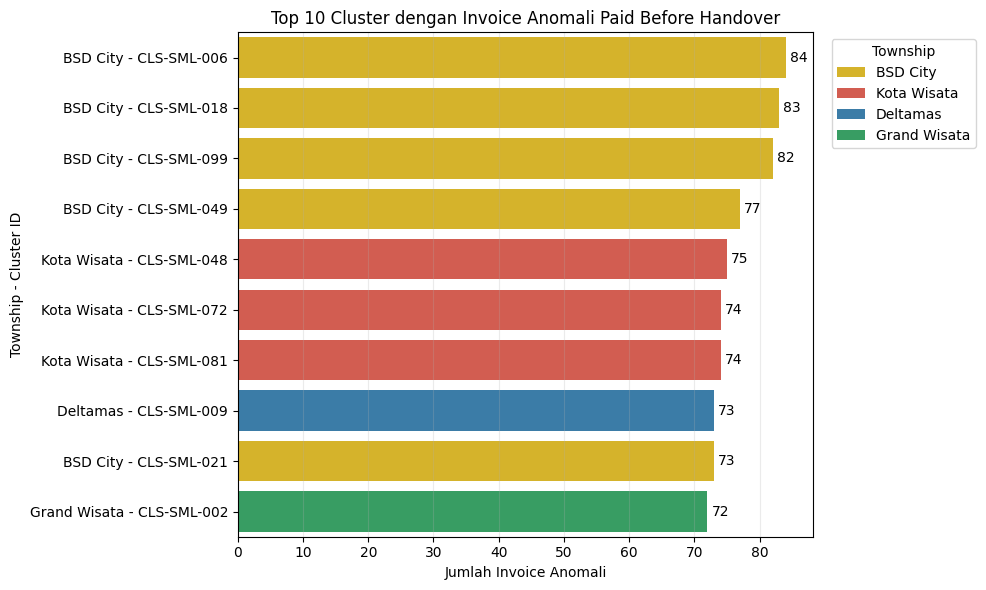

In [ ]:
# Horizontal Barplot: Top 10 Cluster dengan Invoice Anomali
# Paid Before Handover

summary_anomali_cluster = (
    df.groupby(['township_name', 'cluster_id'])
    .agg(
        anomaly_invoice=(
            'paid_before_handover_status',
            lambda x: (x == 'Anomali').sum()
        )
    )
    .reset_index()
)

top10_anomali_cluster = (
    summary_anomali_cluster
    .sort_values('anomaly_invoice', ascending=False)
    .head(10)
    .copy()
)

top10_anomali_cluster['cluster_label'] = (
    top10_anomali_cluster['township_name'] + ' - ' +
    top10_anomali_cluster['cluster_id'].astype(str)
)

top10_anomali_cluster = top10_anomali_cluster.sort_values(
    'anomaly_invoice',
    ascending=False
)

plt.figure(figsize=(10, 6))

grafik = sns.barplot(
    data=top10_anomali_cluster,
    y='cluster_label',
    x='anomaly_invoice',
    hue='township_name',
    palette=township_palette,
    dodge=False,
    errorbar=None
)

for i in grafik.containers:
    grafik.bar_label(i, fmt='%.0f', padding=3)

plt.title('Top 10 Cluster dengan Invoice Anomali Paid Before Handover')
plt.xlabel('Jumlah Invoice Anomali')
plt.ylabel('Township - Cluster ID')
plt.legend(title='Township', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

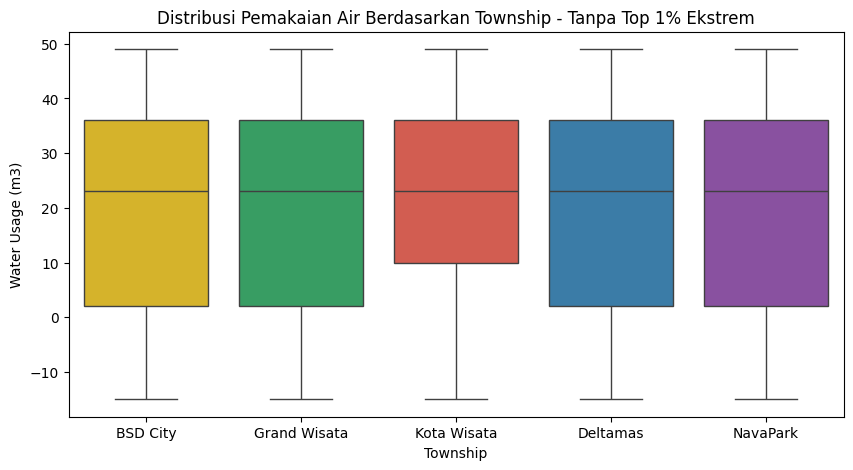

In [ ]:
# Boxplot : Outlier Pemakaian Air

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[df['water_usage_m3'] <= df['water_usage_m3'].quantile(0.99)],
    x='township_name',
    y='water_usage_m3',
    hue='township_name',
    palette=township_palette,
    showfliers=False

)

plt.title('Distribusi Pemakaian Air Berdasarkan Township - Tanpa Top 1% Ekstrem')
plt.xlabel('Township')
plt.ylabel('Water Usage (m3)')
plt.show()

In [ ]:
## MW Test: Pengaruh Occupancy Status terhadap Aging Tunggakan

# Filter hanya invoice tunggakan
df_tunggakan = df[df['payment_status'].isin(['Unpaid', 'Overdue'])].copy()

# Pisahkan aging tunggakan berdasarkan occupancy status
vacant_aging = df_tunggakan[
    df_tunggakan['occupancy_status'] == 'Vacant'
]['aging_tunggakan_bulan'].dropna()

occupied_aging = df_tunggakan[
    df_tunggakan['occupancy_status'] == 'Occupied'
]['aging_tunggakan_bulan'].dropna()

# Mann-Whitney U Test
stat, p_value = mannwhitneyu(
    vacant_aging,
    occupied_aging,
    alternative='two-sided'
)

print('Mann-Whitney U Statistic:', stat)
print('P-value:', p_value)

if p_value < 0.05:
    print('Kesimpulan: Terdapat perbedaan signifikan aging tunggakan antara unit Vacant dan Occupied.')
else:
    print('Kesimpulan: Tidak terdapat perbedaan signifikan aging tunggakan antara unit Vacant dan Occupied.')

Mann-Whitney U Statistic: 1020344004.0
P-value: 0.674254403266988
Kesimpulan: Tidak terdapat perbedaan signifikan aging tunggakan antara unit Vacant dan Occupied.


In [ ]:
## Chi-Square Test: Hubungan Vacant Status terhadap Status Tunggakan

# Buat status tunggakan
df['tunggakan_status'] = np.where(
    df['payment_status'].isin(['Unpaid', 'Overdue']),
    'Tunggakan',
    'Lunas'
)

# Crosstab
contingency_table = pd.crosstab(
    df['occupancy_status'],
    df['tunggakan_status']
)

display(contingency_table)

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print('Chi-square Statistic:', chi2)
print('P-value:', p_value)
print('Degree of Freedom:', dof)

if p_value < 0.05:
    print('Kesimpulan: Terdapat hubungan signifikan antara Vacant Status dan Status Tunggakan.')
else:
    print('Kesimpulan: Tidak terdapat hubungan signifikan antara Vacant Status dan Status Tunggakan.')

tunggakan_status,Lunas,Tunggakan
occupancy_status,,
Occupied,179993,45499
Vacant,29729,44779


Chi-square Statistic: 42426.09166044892
P-value: 0.0
Degree of Freedom: 1
Kesimpulan: Terdapat hubungan signifikan antara Vacant Status dan Status Tunggakan.


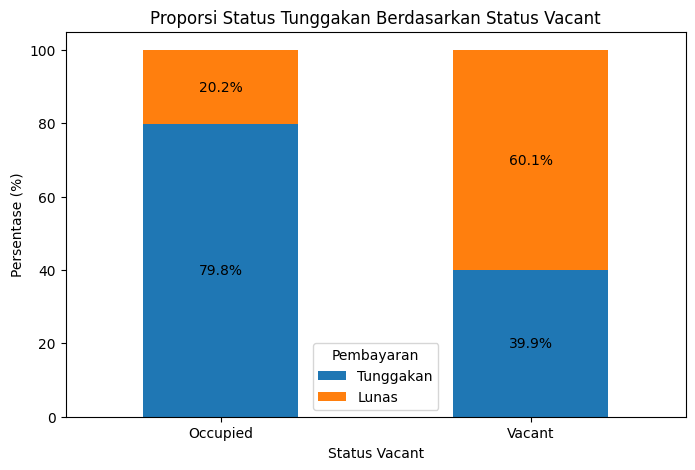

In [ ]:
# Buat crosstab dalam bentuk persentase per baris
ct_percent = pd.crosstab(
    df['occupancy_status'],
    df['tunggakan_status'],
    normalize='index'
) * 100

ct_percent

# Visualisasi

ct_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Proporsi Status Tunggakan Berdasarkan Status Vacant')
plt.xlabel('Status Vacant')
plt.ylabel('Persentase (%)')
plt.legend(title='Pembayaran', labels=['Tunggakan', 'Lunas'])
plt.xticks(rotation=0)

for container in plt.gca().containers:
    plt.bar_label(container, fmt='%.1f%%', label_type='center')

plt.show()

Crosstab Missing Contact vs Status Tunggakan:


tunggakan_status,Lunas,Tunggakan
contact_missing_status,,
Contact Available,167657,72297
Missing Contact,42065,17981


Chi-square Statistic: 0.7654637599002255
P-value: 0.3816240431373533
Degree of Freedom: 1
Kesimpulan: Tidak terdapat hubungan signifikan antara Missing Contact Number dan Status Tunggakan.


,contact_missing_status,total_invoice,total_tunggakan,tunggakan_rate_percent
0,Contact Available,239954,72297,30.13
1,Missing Contact,60046,17981,29.95


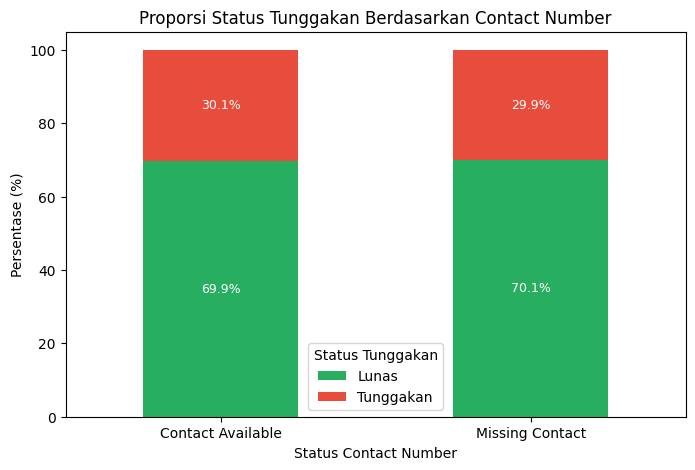

In [ ]:
# Chi-square test: Missing Contact Number terhadap Status Tunggakan

from scipy.stats import chi2_contingency

# 1. Buat status missing contact
df['contact_missing_status'] = np.where(
    df['contact_number'].isna() |
    (df['contact_number'].astype(str).str.strip() == '') |
    (df['contact_number'].astype(str).str.lower().isin(['nan', 'none', 'null'])),
    'Missing Contact',
    'Contact Available'
)

# 2. Crosstab menggunakan kolom status tunggakan yang sudah ada
contact_tunggakan_table = pd.crosstab(
    df['contact_missing_status'],
    df['tunggakan_status']   # ganti jika nama kolom kamu berbeda
)

print("Crosstab Missing Contact vs Status Tunggakan:")
display(contact_tunggakan_table)

# 3. Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contact_tunggakan_table)

print("Chi-square Statistic:", chi2)
print("P-value:", p_value)
print("Degree of Freedom:", dof)

if p_value < 0.05:
    print("Kesimpulan: Terdapat hubungan signifikan antara Missing Contact Number dan Status Tunggakan.")
else:
    print("Kesimpulan: Tidak terdapat hubungan signifikan antara Missing Contact Number dan Status Tunggakan.")

# 4. Summary tunggakan rate berdasarkan contact status
contact_tunggakan_rate = (
    df.groupby('contact_missing_status')
    .agg(
        total_invoice=('invoice_id', 'nunique'),
        total_tunggakan=('is_tunggakan', 'sum')
    )
    .reset_index()
)

contact_tunggakan_rate['tunggakan_rate_percent'] = (
    contact_tunggakan_rate['total_tunggakan'] /
    contact_tunggakan_rate['total_invoice'] * 100
).round(2)

display(contact_tunggakan_rate)

# 5. Visualisasi 100% Stacked Bar Chart
contact_percent = pd.crosstab(
    df['contact_missing_status'],
    df['tunggakan_status'],   # pakai label yang sudah ada
    normalize='index'
) * 100

ax = contact_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=['#27AE60', '#E74C3C']
)

plt.title('Proporsi Status Tunggakan Berdasarkan Contact Number')
plt.xlabel('Status Contact Number')
plt.ylabel('Persentase (%)')
plt.legend(title='Status Tunggakan')
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        color='white',
        fontsize=9
    )

plt.show()

## Drop Kolom Duplikat & Export Clean Data


In [ ]:
# Drop kolom duplikat / tidak diperlukan
df = df.drop(
    columns=[
        'cluster_id_1',
        'unit_id_1',
        'billing_month'
    ],
    errors='ignore'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   cluster_id                   300000 non-null  object        
 1   township_name                300000 non-null  object        
 2   cluster_category             300000 non-null  object        
 3   unit_id                      300000 non-null  object        
 4   owner_name                   300000 non-null  object        
 5   contact_number               239954 non-null  Int64         
 6   is_vacant                    300000 non-null  boolean       
 7   handover_date                300000 non-null  datetime64[ns]
 8   invoice_id                   300000 non-null  object        
 9   water_usage_m3               300000 non-null  float64       
 10  ipl_base_fee                 300000 non-null  Int64         
 11  total_amount              

In [ ]:
# Upload clean data to BigQuery

dataset_id='SML_clean'
table_name='SML_data'
pandas_gbq.to_gbq(
    df,
    f'{dataset_id}.{table_name}',
    project_id=project_id,
    if_exists='replace',
    credentials=credentials
)


100%|██████████| 1/1 [00:00<00:00, 7973.96it/s]
